<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Principal Component Analysis**


## **Introduction**

Principal Component Analysis (**PCA**) is a dimensionality reduction technique. It transforms high-dimensional data into a smaller set of uncorrelated components while preserving as much important variation as possible.

The image below shows the main PCA idea step by step. We start with data that has many features. Because PCA is based on variance, the data is usually standardized first so each feature has a comparable scale. PCA then finds new axes called **principal components**. These axes point in the directions where the data varies the most.

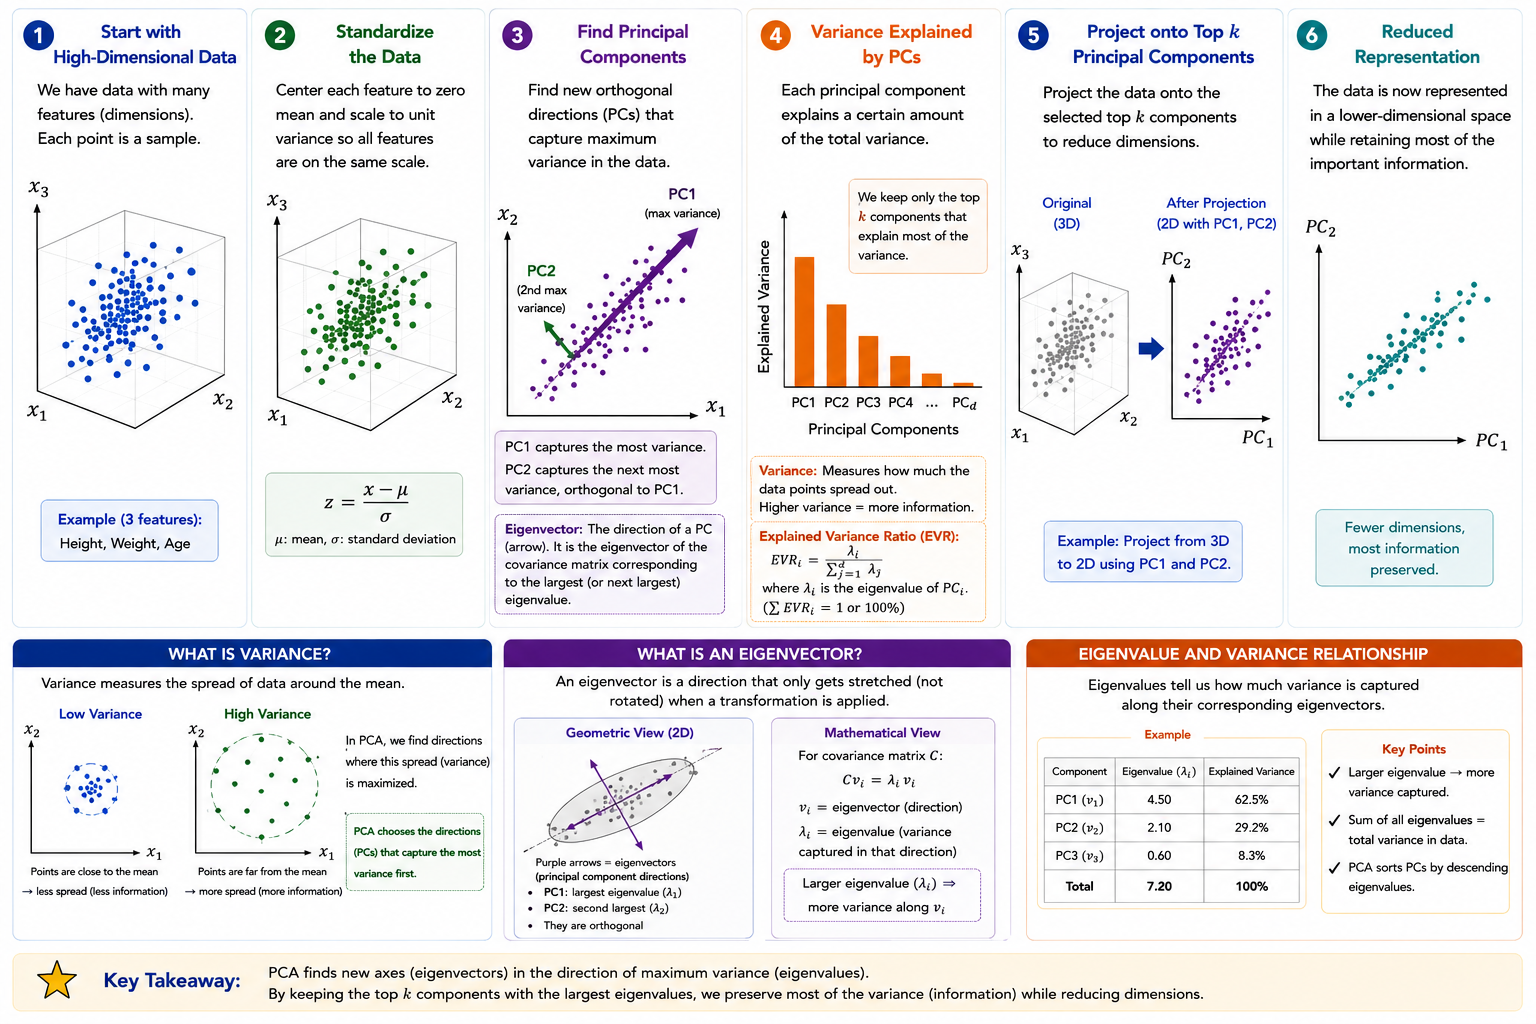

The first principal component explains the largest amount of variance. Each later component explains the largest remaining variance while staying orthogonal to the previous components. By keeping only the top $k$ components, PCA gives a lower-dimensional representation that still keeps most of the useful information.

Before computing principal components, PCA first centers the data by subtracting the mean of each feature:

$$
X_{centered} = X - \bar{X}
$$

PCA is then computed from the covariance matrix of the centered data:

$$
C = \frac{1}{n-1}X_{centered}^TX_{centered}
$$

where:
- rows represent samples
- columns represent features
- $X_{centered}^T$ is the transpose of the centered data matrix
- $n$ is the number of samples

The covariance matrix measures how features vary together across the dataset:
- positive covariance means features increase together
- negative covariance means one feature increases while the other decreases
- near-zero covariance means the relationship between features is weak

PCA then computes the eigenvectors and eigenvalues of the covariance matrix. The eigenvectors define the principal component directions, and the eigenvalues indicate how much variance is explained by each component.


### **Use Cases of PCA**

PCA is useful when a dataset has many features and we want a smaller, clearer representation. The overview image shows this idea: PCA keeps the directions with the most variation and removes directions that carry less information.

Common use cases include:

* Facial recognition
* Image compression
* Visualization of high-dimensional data
* Identifying patterns in financial, scientific, or business data

For instance, suppose you are a fund manager analyzing a portfolio of 200 stocks. Studying the relationships among all stocks may require working with a 200 $\times$ 200 correlation or covariance matrix, which can be difficult to interpret directly.

Rather than analyzing every original variable separately, PCA can help identify a smaller number of dominant directions that summarize the most important patterns of variation in the portfolio.

In this way, PCA reduces the dimensionality of a complex problem while retaining the information that explains the most variation in the data.


In this notebook, you will explore how to simplify and reduce the dimensionality of different datasets using **Principal Component Analysis** (PCA). You will connect the visual idea of principal components to practical Python steps such as scaling data, fitting a PCA model, transforming the data, and interpreting explained variance.


### **Workflow**

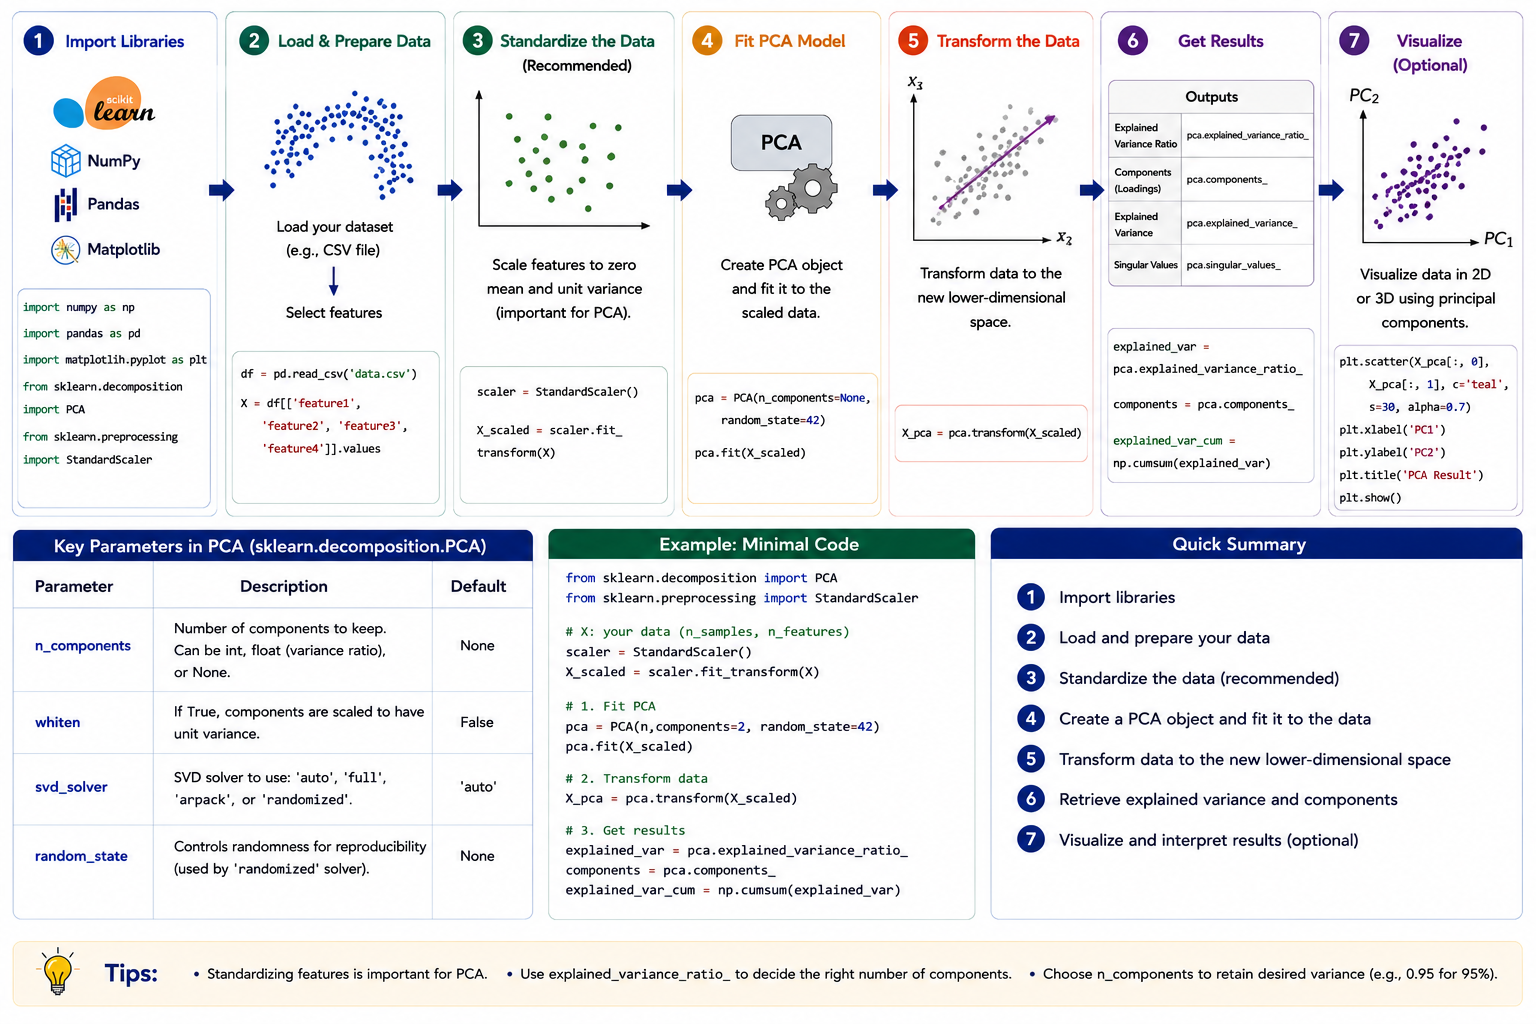

The workflow image above shows how PCA is usually applied with scikit-learn. First, import the required libraries and load the dataset. Next, select the features and standardize the data so each feature has zero mean and unit variance. This step is important because PCA depends on variance, and features with larger scales can otherwise dominate the result.

After scaling, create and fit a `PCA` model. Then transform the data into the new lower-dimensional space. The model outputs useful information such as the explained variance ratio, principal components, explained variance, and singular values. Finally, you can visualize the transformed data and decide how many components are needed to keep enough information.


## __Table of Contents__

1. [Objectives](<#Objectives>)
2. [Datasets](<#Datasets>)
3. [Setup](<#Setup>)
    1. [Installing Required Libraries](<#Installing-Required-Libraries>)
    2. [Importing Required Libraries](<#Importing-Required-Libraries>)
    3. [Defining Helper Functions](<#Defining-Helper-Functions>)
4. [Background](<#Background>)
    1. [What does PCA do?](<#What-does-PCA-do?>)
    2. [How Does PCA Work? (Optional)](<#How-Does-PCA-Work?-(Optional)>)
5. [Visual Example](<#Visual-Example>)
    1. [Scaling Data](<#Scaling-Data>)
    2. [Applying PCA](<#Applying-PCA>)
    3. [Putting it all Together](<#Putting-it-all-Together>)
6. [Using PCA to Improve Facial Recognition](<#Using-PCA-to-Improve-Facial-Recognition>)
7. [Exercises](<#Exercises>)
    1. [Exercise 1 - Scaling the Data](<#Exercise-1---Scaling-the-Data>)
    2. [Exercise 2 - Fitting PCA Object](<#Exercise-2---Fitting-PCA-Object>)
    3. [Exercise 3 - Finding Desired Number of Components](<#Exercise-3---Finding-Desired-Number-of-Components>)
    4. [Exercise 4 - Dimensionality Reduction](<#Exercise-4---Dimensionality-Reduction>)


***


## **Objectives**


After completing this lab you will be able to:


*   **Understand** what PCA is and how (generally) it works.
*   **Understand** when PCA is useful.
*   **Apply** PCA effectively.


## **Datasets**

Datasets for this lab are gathered from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2022-01-01) under the MIT License.


## **Setup**


For this lab, we will be using the following libraries:

*   [`pandas`](https://pandas.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2022-01-01) for managing the data.
*   [`numpy`](https://numpy.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2022-01-01) for mathematical operations.
*   [`sklearn`](https://scikit-learn.org/stable/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2022-01-01) for machine learning and machine-learning-pipeline related functions.
*   [`seaborn`](https://seaborn.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2022-01-01) for visualizing the data.
*   [`matplotlib`](https://matplotlib.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2022-01-01) for additional plotting tools.


### **Installing Required Libraries**

The following required modules are pre-installed in the Skills Network Labs environment. However if you run this notebook commands in a different Jupyter environment (e.g. Watson Studio or locally) you will need to install these libraries by removing the `#` sign before `!mamba` in the code cell below.


In [153]:
# All Libraries required for this lab are listed below. The libraries pre-installed on Skills Network Labs are commented.
# !mamba install -qy pandas==1.3.4 numpy==1.21.4 seaborn==0.9.0 matplotlib==3.5.0 scikit-learn==0.20.1
# Note: If your environment doesn't support "!mamba install", use "!pip install pandas==1.3.4 ..."

### **Importing Required Libraries**


In [154]:
# Surpress warnings from using older version of sklearn:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

from tqdm import tqdm
import numpy as np
import pandas as pd
from itertools import accumulate

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.datasets import fetch_lfw_people
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.svm import SVC
from scipy.stats import loguniform

warnings.filterwarnings('ignore')

sns.set_context('notebook')
sns.set_style('white')

### **Defining Helper Functions**

Below, we define helper functions to simplify your code later on:


In [155]:
def plot_explained_variance(pca):
    # This function graphs the accumulated explained variance ratio for a fitted PCA object.
    acc = [*accumulate(pca.explained_variance_ratio_)]
    fig, ax = plt.subplots(1, figsize=(50, 20))
    ax.stackplot(range(pca.n_components_), acc)
    ax.scatter(range(pca.n_components_), acc, color="black")
    ax.set_ylim(0, 1)
    ax.set_xlim(0, pca.n_components_ - 1)
    ax.tick_params(axis="both", labelsize=36)
    ax.set_xlabel("N Components", fontsize=48)
    ax.set_ylabel("Accumulated explained variance", fontsize=48)
    plt.tight_layout()
    plt.show()

## **Background**

Before we begin using **PCA**, we should first understand:

1.  What PCA does
2.  How PCA Works


### **What does PCA do?**

*   Reduces the dimensionality of data. By reducing data dimensionality, PCA can also help with visualization.
*   May reduce noise in the process

\-Can be used to pre-process data improving the result of your algorithm


### **How Does PCA Work? (Optional)**

PCA works by rotating the original feature space into a new coordinate system where the axes are ordered by how much variance they explain.

Suppose the dataset has \(n\) features. After centering the data, PCA computes principal component directions from the covariance matrix. These directions are ordered from the highest explained variance to the lowest.

The first principal component captures the greatest variance. Each subsequent component captures the largest remaining variance while staying orthogonal to the components before it.

The amount of variance explained by each component is measured by its **eigenvalue**:
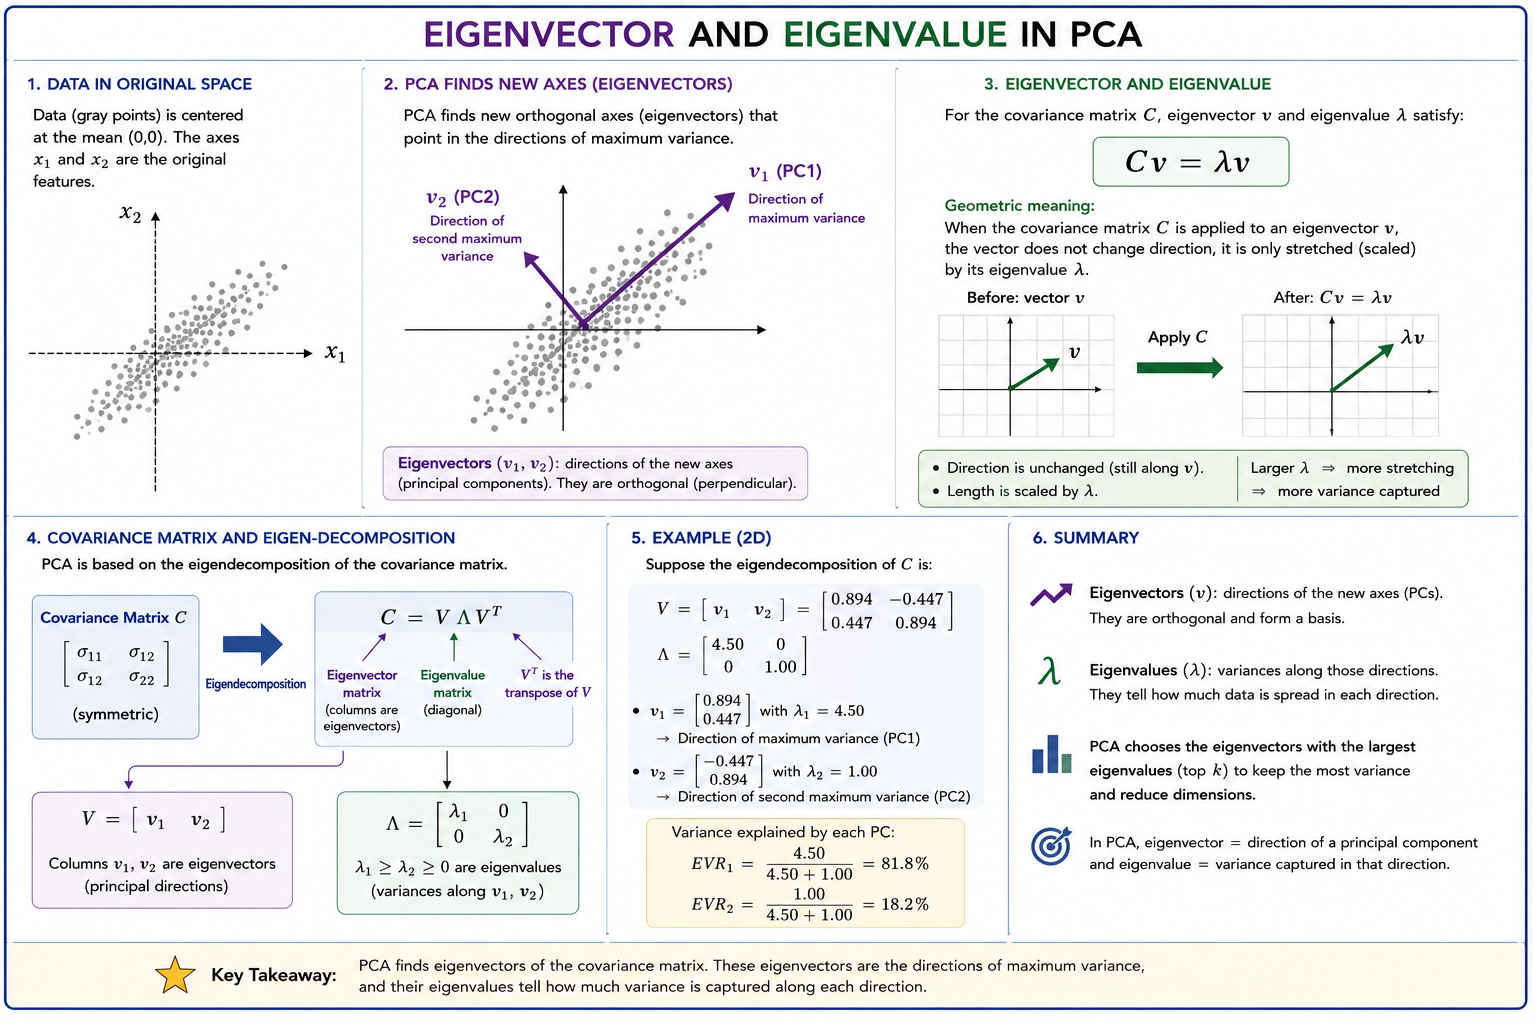
$$
\lambda_1 \ge \lambda_2 \ge \cdots \ge \lambda_n
$$

Larger eigenvalues correspond to directions that explain more variance in the data.

After computing the components, we keep the top \(k\) directions, where:

$$
k \le n
$$

Choosing \(k\) controls the trade-off between dimensionality reduction and retained variance.

The centered data is then projected onto this \(k\)-dimensional subspace:

$$
X_{\text{reduced}} = X_{centered}W_k
$$

where:

- \(X_{centered}\) is the centered data matrix
- \(W_k\) contains the top-\(k\) principal component directions

The result is a lower-dimensional representation that can be used for visualization, noise reduction, or as input to another machine learning model.

## **Visual Example**

Let's look at an example that will visually demonstrate PCA in action.

Load the dataset `HeightsWeights.csv` which contains a list of various people's heights (in inches) and weight (in pounds and kg):


In [156]:
hwdf = pd.read_csv(
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML0187EN-SkillsNetwork/labs/module%203/data/HeightsWeights.csv",
    index_col=0,
)
hwdf.head()

,Height(Inches),Weight(Pounds),Weight(Kilograms)
Index,,,
1,65.78331,112.9925,51.253062
2,71.51521,136.4873,61.910233
3,69.39874,153.0269,69.412546
4,68.21660,142.3354,64.562914
5,67.78781,144.2971,65.452735


### **Scaling Data**

Before applying PCA, the data should usually be scaled.

PCA is strongly affected by the variance of each feature. Features with larger numerical ranges naturally have larger variances and can dominate the principal components.

For example, suppose one feature ranges from: $0 \text{ to } 1$ 

while another ranges from:  $ 0 \text{ to } 1000$

The second feature will contribute much more to the variance, even if it is not more important.

To avoid this problem, features are commonly standardized using:

$$
z = \frac{x-\mu}{\sigma}
$$

where:
- $x$ is the original value
- $\mu$ is the feature mean
- $\sigma$ is the standard deviation

After scaling:

- each feature has mean \(0\)
- each feature has standard deviation \(1\)

This gives all features similar weight and allows PCA to identify the most meaningful directions in the data without being biased toward large-scale features.

Scaling also improves numerical stability and often helps machine learning algorithms perform better.

We can scale the data using `StandardScaler` from `sklearn.preprocessing`.

In [157]:
scaler = StandardScaler()
hwdf[:] = scaler.fit_transform(hwdf)
hwdf.columns = [f"{c} (scaled)" for c in hwdf.columns]
hwdf.head()

,Height(Inches) (scaled),Weight(Pounds) (scaled),Weight(Kilograms) (scaled)
Index,,,
1,-1.162051,-1.208072,-1.208072
2,1.852136,0.806805,0.806805
3,0.739165,2.225214,2.225214
4,0.117523,1.308328,1.308328
5,-0.107961,1.476561,1.476561


Let's look at 3-D plot of our data (one dimension per feature):


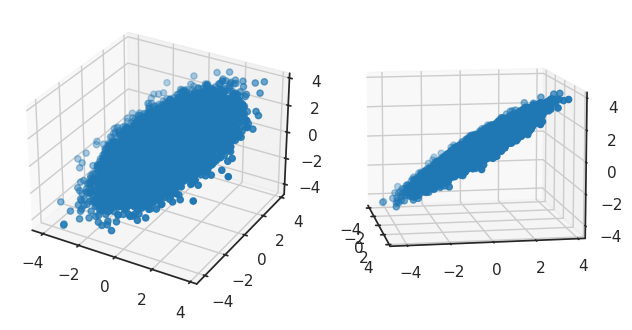

In [158]:
fig = plt.figure()
ax1 = fig.add_subplot(121, projection="3d")
xs, ys, zs = [hwdf[attr] for attr in hwdf.columns]
ax1.scatter(xs, ys, zs)

ax2 = fig.add_subplot(122, projection="3d")
xs, ys, zs = [hwdf[attr] for attr in hwdf.columns]
ax2.view_init(elev=10, azim=-10)  # Change viewing angle
ax2.scatter(xs, ys, zs)

plt.tight_layout()
plt.show()

As you can see, our data here forms a plane.

This is because the *weight in kilograms does not provide any more information than weight in pounds* (or vice-versa).

This becomes clear with the following, alternate perspective, showing the 2d relationships between the pairs of data and calculating the correlation  :


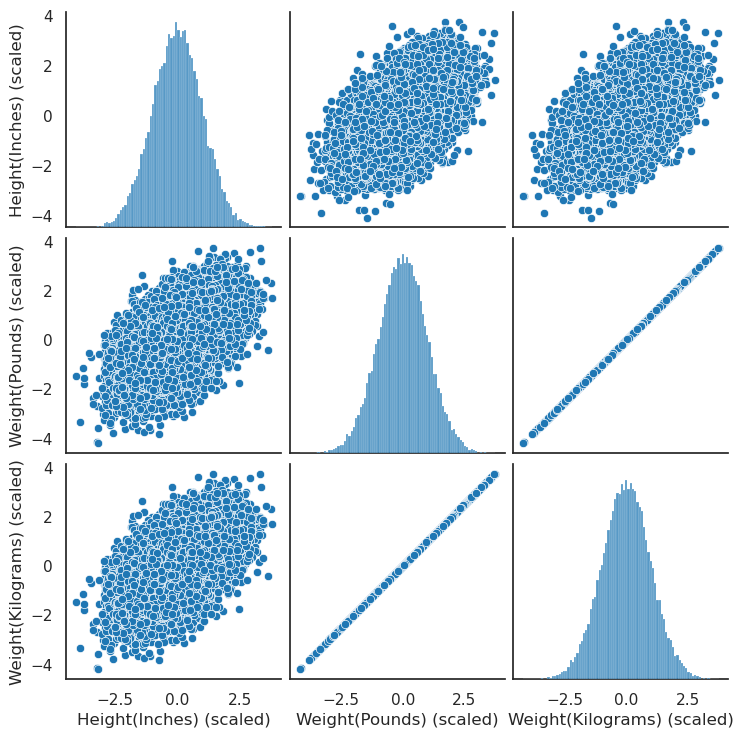

In [159]:
sns.pairplot(hwdf)
plt.show()

In [160]:
hwdf.corr().style.background_gradient(cmap="coolwarm")

,Height(Inches) (scaled),Weight(Pounds) (scaled),Weight(Kilograms) (scaled)
Height(Inches) (scaled),1.000000,0.502859,0.502859
Weight(Pounds) (scaled),0.502859,1.000000,1.000000
Weight(Kilograms) (scaled),0.502859,1.000000,1.000000


We see the weights are perfectly correlated, which means **Weight(Pounds)** tells us everything we need to know about **Weight(Kilograms)** ,thus we have clearly **redundant** data! Although, this example is exaggerated, it'll help demonstrate where PCA shines.


<b>Note</b> Standardizing your data before applying PCA is called *whitening*.


### **Applying PCA**

It's time to apply PCA, let's first apply PCA keeping the same dimension as the original data, i.e.: `n_components=3`.


In [161]:
pca = PCA()
pca.fit(hwdf)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


We can find the projection of the dataset onto the principal components call it `Xhat` , this is our "new" dataset, it is the same shape as the original dataset


In [162]:
Xhat = pca.transform(hwdf)
Xhat.shape

(25000, 3)

Let’s look at the new dataset as a dataframe.


In [163]:
hwdf_PCA = pd.DataFrame(
    columns=[
        f"Projection on Component {i+1}" for i in range(len(hwdf.columns))
    ],
    data=Xhat,
)
hwdf_PCA.head()

,Projection on Component 1,Projection on Component 2,Projection on Component 3
0,-2.051774,-0.243847,1.171536e-15
1,1.866218,1.117813,1.723353e-16
2,3.133436,-0.794420,6.131301e-17
3,1.696186,-0.748473,-4.937985e-16
4,1.803402,-1.058234,-3.827762e-16


**Why** are the values in the third column all essentially zero?

Let's look at the principal components:


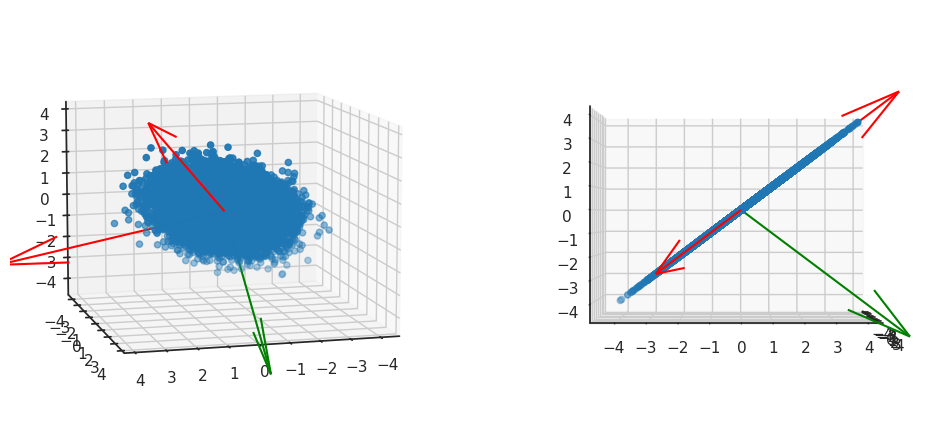

red component accounts for 78.98% of explained variance
red component accounts for 21.02% of explained variance
green component accounts for 0.00% of explained variance


In [164]:
colors = ["red", "red", "green"]

fig = plt.figure(figsize=(12, 8))
ax1 = fig.add_subplot(121, projection="3d")
xs, ys, zs = [hwdf[attr] for attr in hwdf.columns]
ax1.view_init(elev=10, azim=75)
ax1.scatter(xs, ys, zs)

for component, color in zip(pca.components_, colors):
    ax1.quiver(*[0, 0, 0], *(8 * component), color=color)


ax2 = fig.add_subplot(122, projection="3d")
xs, ys, zs = [hwdf[attr] for attr in hwdf.columns]
ax2.view_init(elev=0, azim=0)
ax2.scatter(xs, ys, zs)

for component, color in zip(pca.components_, colors):
    ax2.quiver(*[0, 0, 0], *(8 * component), color=color)

plt.show()

for color, ev in zip(colors, pca.explained_variance_ratio_):
    print(
        f"{color} component accounts for {ev * 100:.2f}% of explained variance"
    )

This means most of the information in the dataset lies along the first two principal components.The transformed dataset:`Xhat` is obtained by projecting the original data `hwdf` onto the principal component directions:`Xhat` = $XW$ where $W$ contains the principal component vectors.In the figure, most data points are aligned with the two red components, showing that these directions contain most of the variation in the data. The green component is nearly perpendicular to the data distribution, so it contributes very little information.Because the third component explains almost no variance, it can be removed with minimal information loss. This allows PCA to reduce the dimensionality of the dataset while preserving the most important structure.

We convert this new data to a Dataframe and see the points appear uncorrelated:


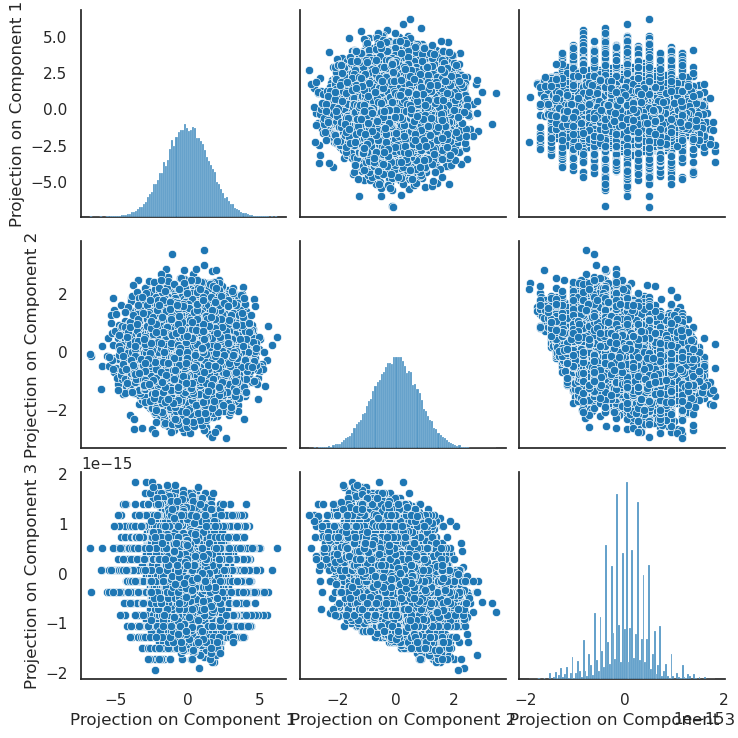

In [165]:
sns.pairplot(hwdf_PCA)
plt.show()

In [166]:
hwdf_PCA.corr().style.background_gradient(cmap="coolwarm")

,Projection on Component 1,Projection on Component 2,Projection on Component 3
Projection on Component 1,1.000000,0.000000,-0.059300
Projection on Component 2,0.000000,1.000000,-0.365041
Projection on Component 3,-0.059300,-0.365041,1.000000


As you can see, the correlations of the 3 principal components are now zero, meaning we have successfully de-correlated `hwdf` and obtained features that are linearly independent of each other.

Each component provides variance/information on a different direction. As we saw before that, the third component had a small projection, which means it doesn't provide much information about our original data `hwdf` in the new feature space.

Thus, we can remove the third dimension, while still keeping the vast majority of our data's information:


In [167]:
hwdf_PCA.drop("Projection on Component 3", axis=1, inplace=True)
hwdf_PCA.head()

,Projection on Component 1,Projection on Component 2
0,-2.051774,-0.243847
1,1.866218,1.117813
2,3.133436,-0.794420
3,1.696186,-0.748473
4,1.803402,-1.058234


### **Putting it all Together**


Now that you have some intuition behind PCA, let's start from the beginning and understand the PCA-pipeline.

In **sklearn.decomposition.PCA**, there is a parameter called `whiten` which helps standardize your input data if you set `whiten = True`. You could also use `StandardScaler()` as a separate step before using PCA.


In [168]:
scaler = StandardScaler()
X = pd.DataFrame(
    scaler.fit_transform(hwdf), index=hwdf.index, columns=hwdf.columns
)
X.head()

pca = PCA()
X_PCA = pd.DataFrame(
    pca.fit_transform(X),
    index=X.index,
    columns=[f"Component {i}" for i in range(pca.n_components_)],
)
# (Remember it's technically "Projection onto Component {i}")
X_PCA.head()

,Component 0,Component 1,Component 2
Index,,,
1,-2.051774,-0.243847,1.006988e-15
2,1.866218,1.117813,6.739215e-16
3,3.133436,-0.794420,2.298323e-16
4,1.696186,-0.748473,-4.363016e-16
5,1.803402,-1.058234,-2.142569e-16


By default, `sklearn.decomposition.PCA` sorts the components by their explained variance.

Let's analyze the explained variance ratios:


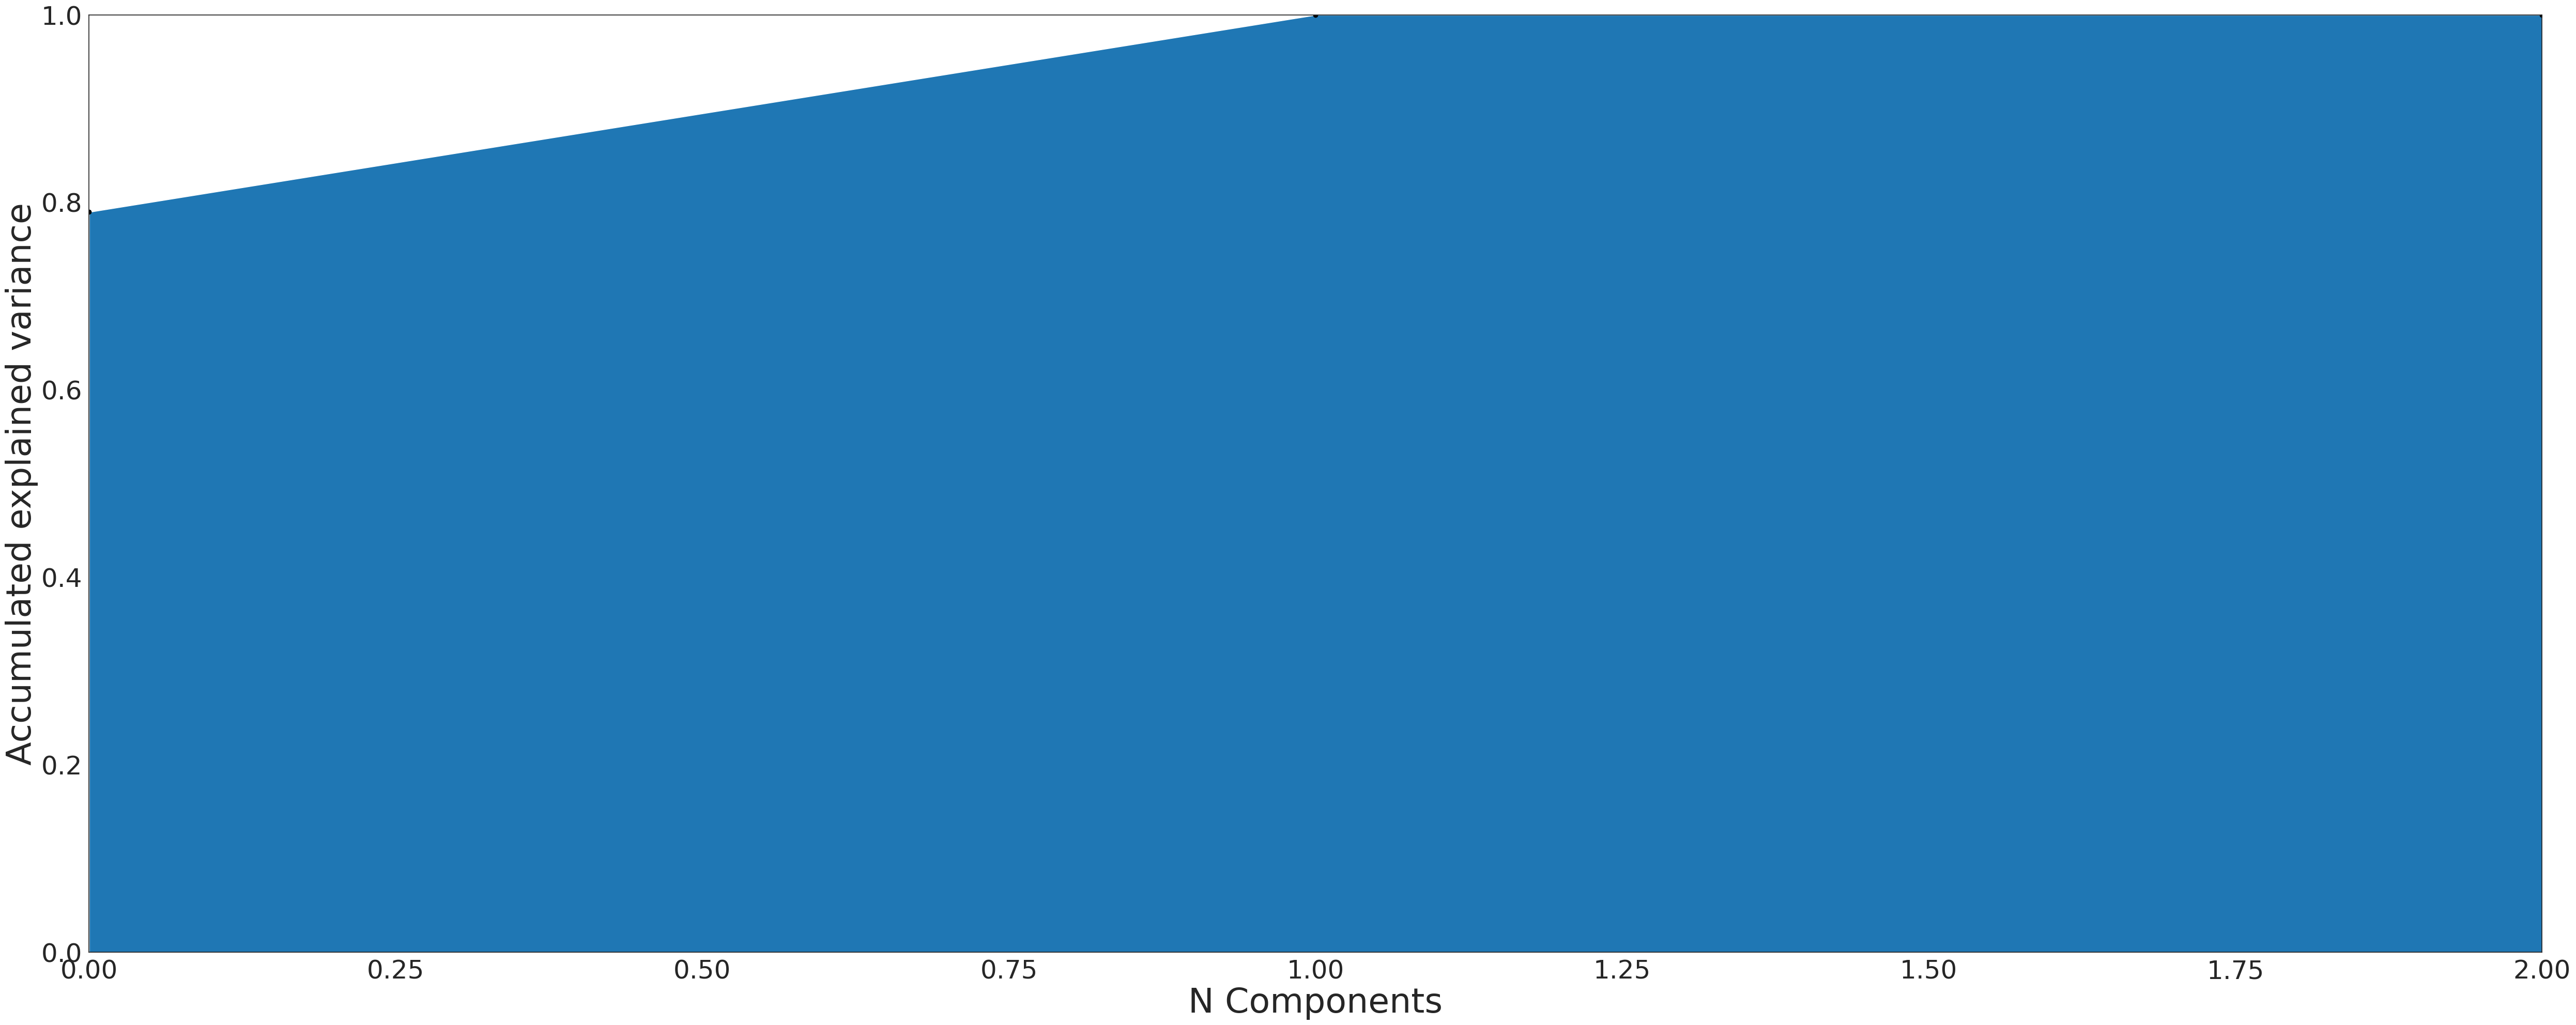

In [169]:
plot_explained_variance(pca)

Suppose a $99%$ threshold is sufficient for our task, let's see how many components (dimensions) we can drop:


In [ ]:
pca = PCA(n_components=0.99)

X_PCA = pd.DataFrame(
    pca.fit_transform(X),
    index=X.index,
    columns=[f"Component {i+1}" for i in range(pca.n_components_)],
)

discarded = X.shape[1] - pca.n_components_

print(
    f"We keep the first {pca.n_components_} principal components "
    f"and discard the remaining {discarded} components."
)

print(
    f"The selected components preserve at least 99% " f"of the total variance."
)

We keep the first 2 principal components and discard the remaining 1 components.
The selected components preserve at least 99% of the total variance.


In [171]:
X_PCA.drop(
    [f"Component {i+1}" for i in range(pca.n_components_, X_PCA.shape[1])],
    axis=1,
    inplace=True,
)
X_PCA.head()

,Component 1,Component 2
Index,,
1,-2.051774,-0.243847
2,1.866218,1.117813
3,3.133436,-0.794420
4,1.696186,-0.748473
5,1.803402,-1.058234


## **Using PCA to Improve Facial Recognition**

PCA is commonly used in facial recognition through a method called **Eigenfaces**.

The main idea is to represent face images using a smaller number of important patterns instead of using every pixel directly.

Suppose each face image has size: $a \times b$ pixels.

Each image is first flattened into a vector of length:  $ a \cdot b$

For example, a $100 \times 100$ image becomes a vector with:  $ 100 \times 100 = 10{,}000 $ features.

All image vectors are combined into a data matrix, and PCA is applied to find the principal components: $ X_{\text{reduced}} = XW $

where:

- $X$ is the original image matrix
- $W$ contains the principal components

These principal components are called **eigenfaces** because they represent the main facial patterns learned from the dataset.

Instead of storing all original pixels, we keep only the top \(C\) principal components that preserve most of the variance in the images.

This reduces dimensionality while preserving the most important facial information can then be used for:

- facial recognition
- image compression
- noise reduction

*PCA improves efficiency because the model works with a much smaller set of meaningful features instead of thousands of raw pixels.*

Load the Labeled Faces in the Wild (LFW) people datasetclassification


In [172]:
lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=0.4)
lfw_people

{'data': array([[0.99607843, 0.9973857 , 0.9908497 , ..., 0.37908497, 0.38823533,
         0.38169935],
        [0.1503268 , 0.19607843, 0.1764706 , ..., 0.45882353, 0.44313726,
         0.53594774],
        [0.3398693 , 0.39607847, 0.49150327, ..., 0.7098039 , 0.72287583,
         0.7176471 ],
        ...,
        [0.3633987 , 0.3372549 , 0.30718955, ..., 0.19607843, 0.22091503,
         0.19346406],
        [0.19346406, 0.24705882, 0.34248367, ..., 0.7372549 , 0.6653595 ,
         0.6117647 ],
        [0.11633987, 0.10196079, 0.1254902 , ..., 0.13202615, 0.13594772,
         0.2535948 ]], dtype=float32),
 'images': array([[[0.99607843, 0.9973857 , 0.9908497 , ..., 0.29803923,
          0.24705882, 0.20784314],
         [0.99607843, 0.99346405, 0.9908497 , ..., 0.30588236,
          0.2535948 , 0.21699347],
         [0.96078426, 0.93071896, 0.86797386, ..., 0.28627452,
          0.24313726, 0.21568628],
         ...,
         [0.34509805, 0.26143792, 0.1764706 , ..., 0.42352942,
     

The main data structures are:

| Key            | Shape            | Meaning                        |
| -------------- | ---------------- | ------------------------------ |
| `data`         | `(1288, 1850)`   | Flattened face images          |
| `images`       | `(1288, 50, 37)` | Original 2D face images        |
| `target`       | `(1288,)`        | Integer labels for each person |
| `target_names` | `(7,)`           | Names corresponding to labels  |
| `DESCR`        | string           | Dataset description            |


Introspect the images arrays to find the shapes (for plotting)


In [173]:
# introspect the images arrays to find the shapes (for plotting)
N, h, w = lfw_people.images.shape
target_names = lfw_people.target_names

We load our features <code>X</code> and labels <code>y</code>. The images are flattened such that each one is a row in the NumPy array <code>X</code>


In [174]:
y = lfw_people.target
X = lfw_people.data
n_features = X.shape[1]

We plot out each class and an image belonging to that class:


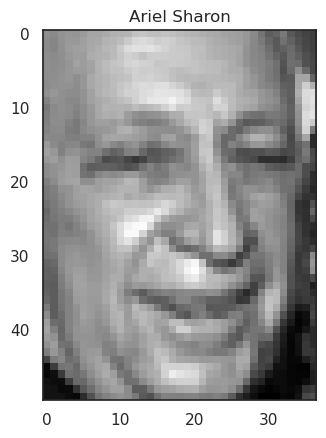

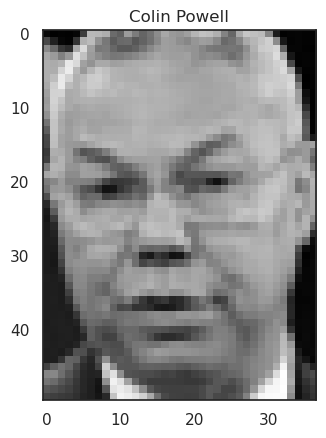

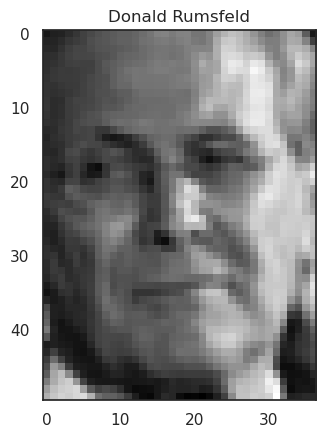

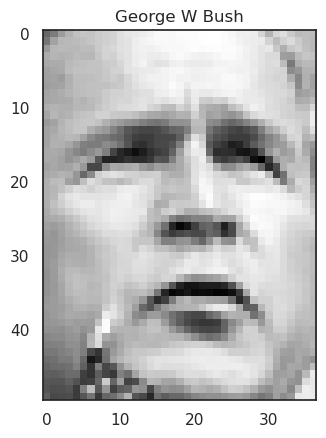

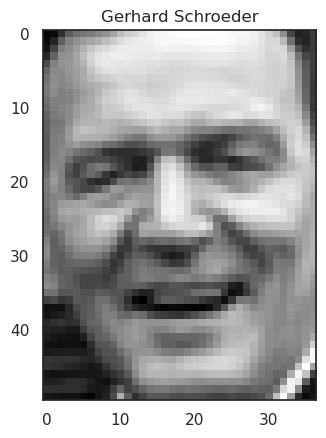

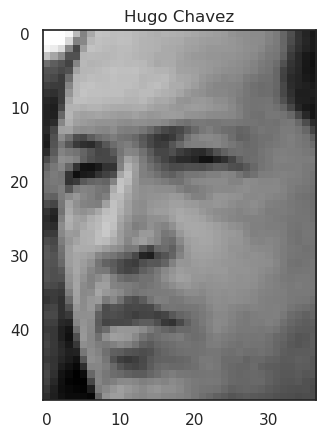

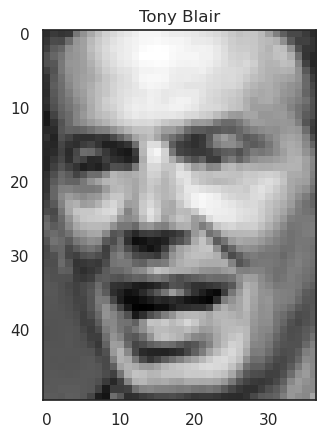

In [ ]:
for person in np.unique(lfw_people.target):
    idx = np.argmax(
        lfw_people.target == person
    )  # Get the index of the first image of the person
    plt.imshow(
        lfw_people.images[idx], cmap="gray"
    )  # Plot the image of the person
    plt.title(lfw_people.target_names[person])
    plt.show()

We split the data into training and testing


In [176]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

Before applying PCA, we first train a Support Vector Machine (SVM) on the original flattened pixel features. This gives us a baseline model to compare against the PCA-based approach.

This step helps answer an important question: does PCA actually improve the facial recognition workflow? By evaluating SVM performance before PCA, we can see how the classifier behaves with the full high-dimensional image data. Then, after PCA reduces the feature space to the most important facial patterns, we train SVM again and compare the results. If performance improves or stays similar while using far fewer features, PCA has made the model more efficient and possibly easier to generalize.


In [177]:
param_grid = {"C": loguniform(1e3, 1e5), "gamma": loguniform(1e-4, 1e-1)}
clf = RandomizedSearchCV(
    SVC(kernel="rbf", class_weight="balanced"), param_grid, n_iter=10
)
clf = clf.fit(X_train, y_train)

We make a prediction using the test data:


In [178]:
y_pred = clf.predict(X_test)

Let's see how well our `SVC` did on the test data:


Text(46.24999999999999, 0.5, 'Truth Value')

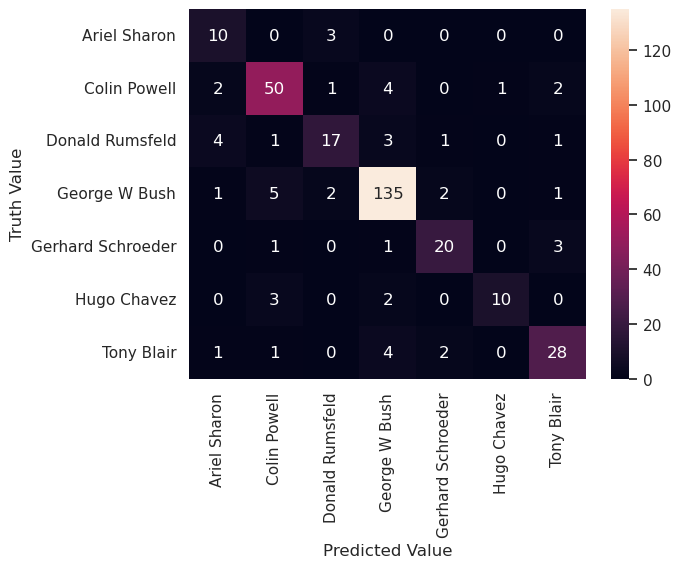

In [179]:
hmap = sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    xticklabels=lfw_people.target_names,
    yticklabels=lfw_people.target_names,
    fmt="g",
)
hmap.set_xlabel("Predicted Value")
hmap.set_ylabel("Truth Value")

The confusion matrix shows that several images from other people are incorrectly predicted as George W Bush.

This can be seen from the off-diagonal values in the "George W Bush" prediction column. For example:

- Colin Powell → George W Bush: 4
- Donald Rumsfeld → George W Bush: 4
- Tony Blair → George W Bush: 7

This suggests the classifier tends to over-predict the George W Bush class, likely because that class contains more training images than the others.


Now, let’s try using PCA, we fit a PCA model :


In [180]:
pca = PCA(svd_solver="full", whiten=True).fit(X_train)

We find the projections onto each principal component for a person in the dataset. We select the sample <code>person_index</code>:


In [181]:
person_index = 1

In [182]:
Xhat = pca.transform(X[person_index, :].reshape(1, -1))

We can find the projections back to each component, i.e the inverse transform;as we use all the non-zero components the images are identical.


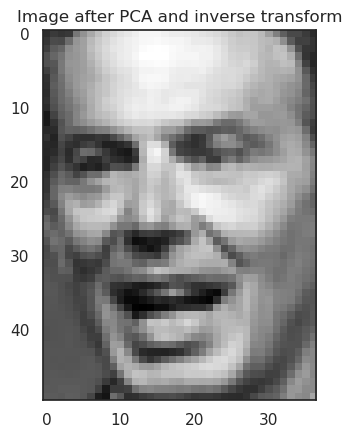

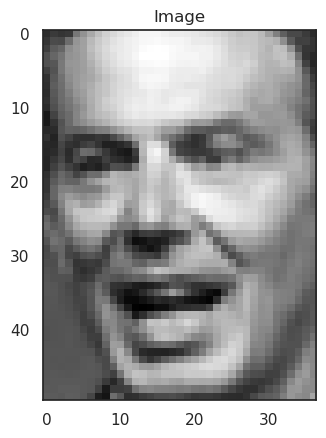

In [183]:
plt.imshow(pca.inverse_transform(Xhat).reshape(h, w), cmap="gray")
plt.title("Image after PCA and inverse transform")
plt.show()
plt.imshow(lfw_people.images[person_index], cmap="gray")
plt.title("Image")
plt.show()

We can use the Explained variance-ratio to determine the number of components to keep, we can plot it as Cumulative distribution.


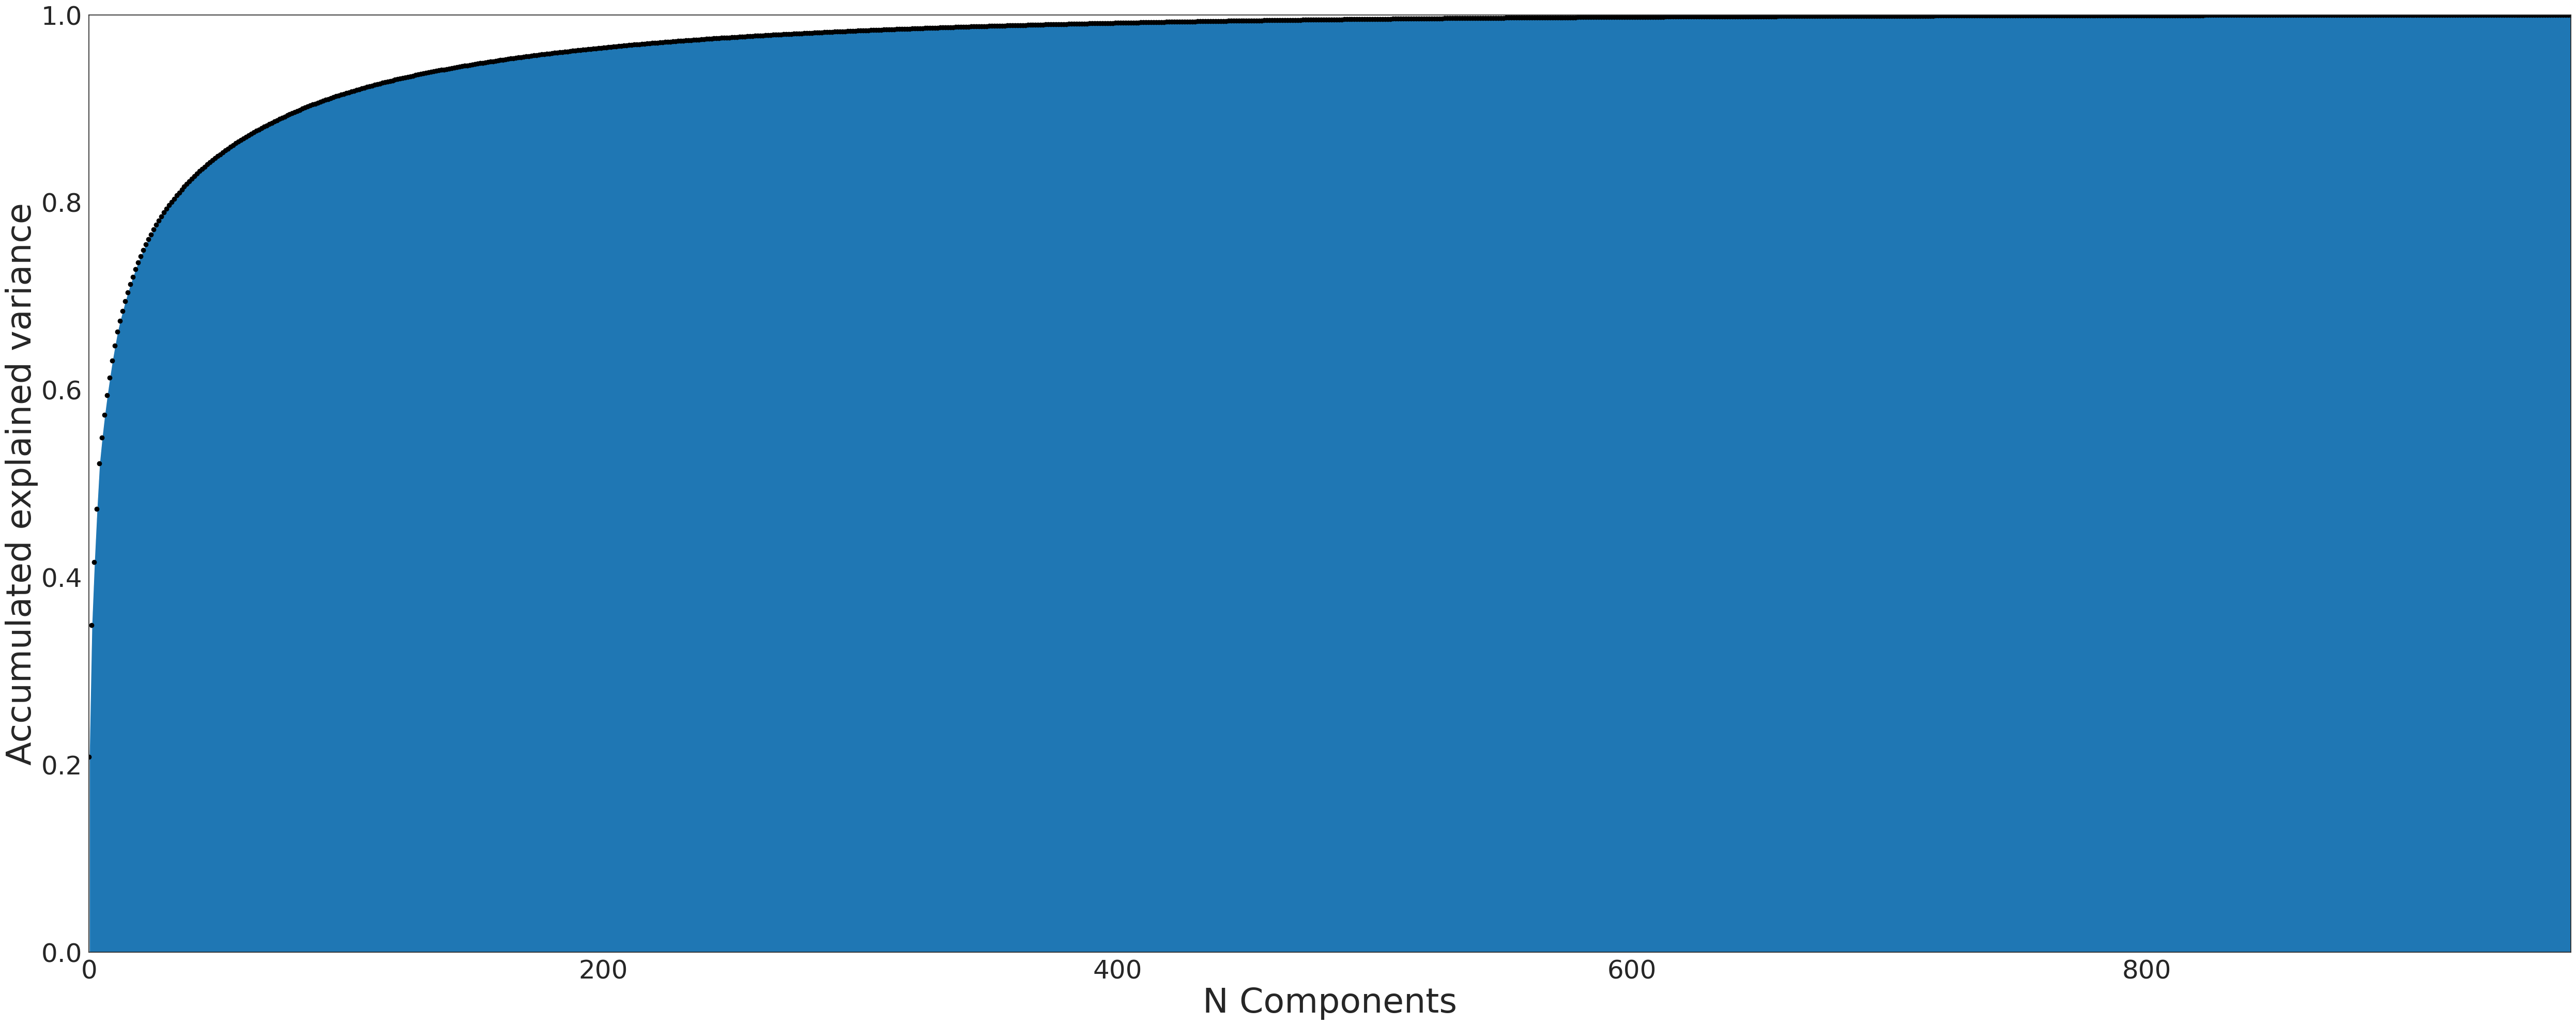

In [184]:
plot_explained_variance(pca)
plt.show()

It looks like 150 components explain over 95% of the variance, usually 80% will do, let’s try and visualize some components.

<p>
<b>Note:</b> you can use Cross-validation to select the number of components  
</p>


Let’s select the  components that explain over 60% of the variance


In [185]:
threshold = 0.60

This corresponds to 7 principal components


In [186]:
components = np.cumsum(pca.explained_variance_ratio_) < threshold
components.sum()

8

We can reshape the principal components into rectangular images and plot them. Remember that the images are linear combinations of these components.


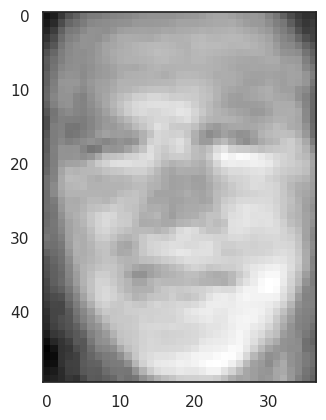

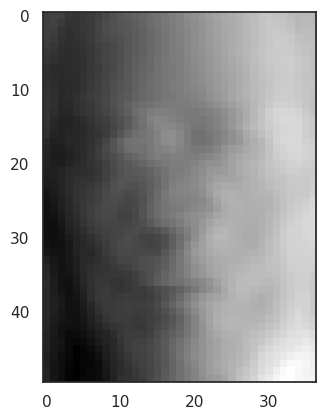

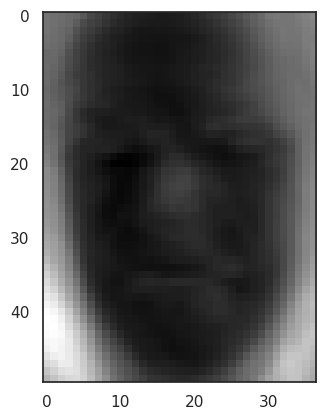

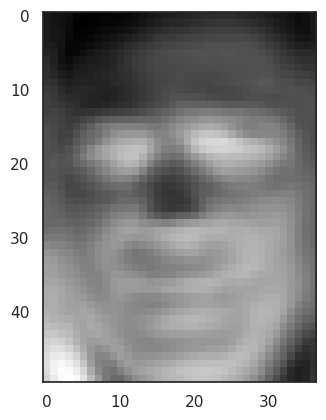

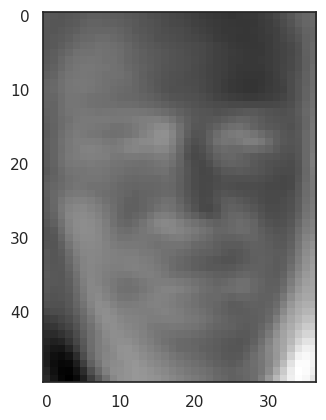

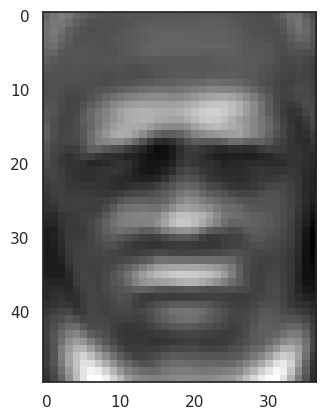

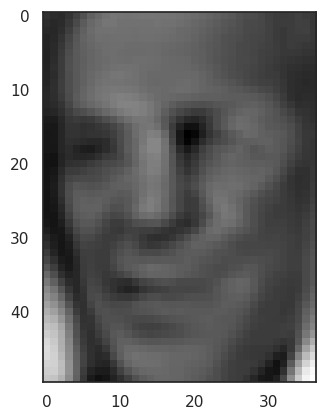

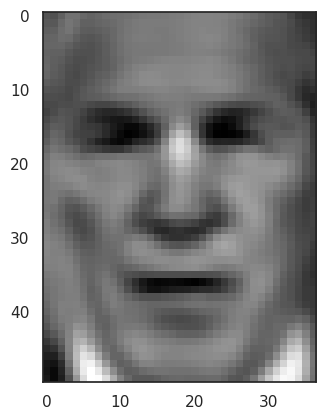

In [187]:
for component in pca.components_[components, :]:
    plt.imshow(component.reshape(h, w), cmap="gray")
    plt.show()

Let's now use PCA with `n_components = 150`:


In [188]:
pca = PCA(n_components=150, svd_solver="randomized", whiten=True).fit(X_train)

We apply the PCA transform on the training and testing data


In [189]:
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

**NOTE**: We can also transform the data back ("inverse_transform") to its original space, with the rest of the components to zero, then convert it to an image. For instance, let's look at one of the images using <code>person_index = 1</code>


In [190]:
person_index = 1

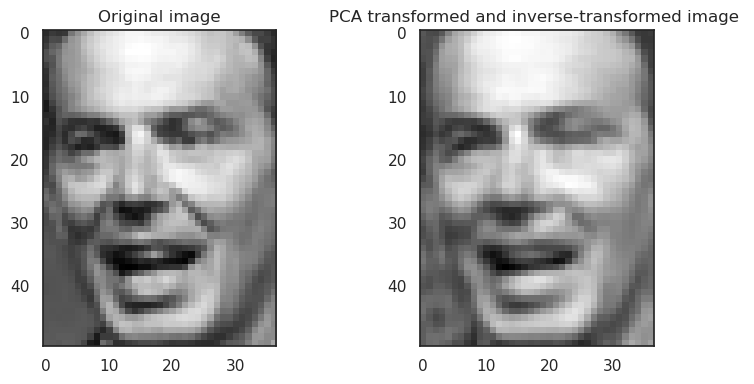

In [191]:
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(lfw_people.images[person_index, :, :], cmap="gray")
plt.title("Original image")

plt.subplot(1, 2, 2)
plt.imshow(
    pca.inverse_transform(
        pca.transform(X[person_index, :].reshape(1, -1))
    ).reshape(h, w),
    cmap="gray",
)
plt.title("PCA transformed and inverse-transformed image ")

plt.tight_layout()
plt.show()

We train the model and find the best Hyperparameters using the transformed data:


In [192]:
param_grid = {
    "C": loguniform(1e3, 1e5),
    "gamma": loguniform(1e-4, 1e-1),
}
clf = RandomizedSearchCV(
    SVC(kernel="rbf", class_weight="balanced"), param_grid, n_iter=10
)

clf = clf.fit(X_train_pca, y_train)

We see the model using PCA performs much better!


In [193]:
y_pred = clf.predict(X_test_pca)

Text(46.24999999999999, 0.5, 'Truth Value')

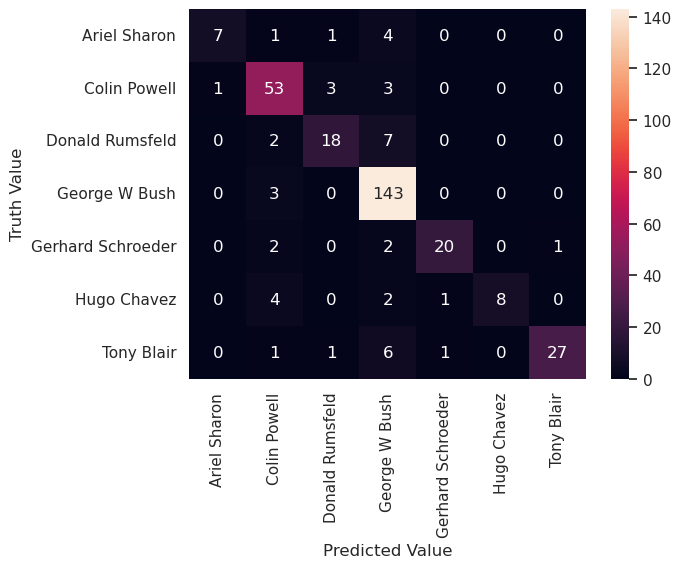

In [194]:
hmap = sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    xticklabels=lfw_people.target_names,
    yticklabels=lfw_people.target_names,
    fmt="g",
)
hmap.set_xlabel("Predicted Value")
hmap.set_ylabel("Truth Value")

The confusion matrix after PCA shows moderate improvement in classification performance.

Several classes have more correct predictions after dimensionality reduction. For example:

- Donald Rumsfeld: $17 \to 21$
- Tony Blair: $25 \to 29$

Some misclassifications toward George W Bush also decreased:

- Tony Blair → George W Bush: $7 \to 4$

This suggests PCA helped remove noisy or redundant features and allowed SVC to focus on the most important facial patterns. However, a few classes, such as George W Bush, showed slightly lower accuracy after PCA.

## **Exercises**

Run the following code cell to complete the exercises

We download and clean the dataset `energydata_complete.csv` containing real-world energy data:


In [195]:
df = pd.read_csv(
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML0187EN-SkillsNetwork/labs/module%203/data/energydata_complete.csv"
)
df.drop("date", axis=1, inplace=True)
df = df.dropna().astype(np.float64)
df.head()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,60.0,30.0,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,60.0,30.0,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,50.0,30.0,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,50.0,40.0,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,60.0,40.0,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


The columns can be described as follows:

*   `Appliances` - energy use of appliances in Wh
*   `lights` - energy use of light fixtures in the house in Wh
*   `T1` - Temperature in kitchen area, in Celsius
*   `RH_1` - Humidity in kitchen area, in $%$
*   `T2` - Temperature in living room area, in Celsius
*   `RH_2` - Humidity in living room area, in $%$
*   $\dots$
*   `To` - Temperature outside (from Chievres weather station), in Celsius
*   `Pressure` - (from Chievres weather station), in mm Hg
*   `RH_out` - Humidity outside (from Chievres weather station), in %
*   `Wind speed` - (from Chievres weather station), in m/s
*   `Visibility` - (from Chievres weather station), in km
*   `Tdewpoint` - (from Chievres weather station), Â°C
*   `rv1`, `rv2` - Random variable 1 & 2, nondimensional

Please see the [data source](https://archive.ics.uci.edu/ml/datasets/Appliances+energy+prediction?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2022-01-01) for more information.


### **Exercise 1 - Scaling the Data**


Scale the data in `df` using sklearn.preprocessing.StandardScaler

(You don't need to change the names of the columns like we did in the examples).


In [196]:
# TODO
scaler = StandardScaler()
df[:] = scaler.fit_transform(df)
df.head()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,-0.367676,3.301264,-1.118645,1.843821,-0.520411,1.073683,-1.235063,1.686130,-0.908217,1.506438,...,-1.217324,0.958136,-0.152647,-2.976328,0.82208,1.207694,2.091596,0.366975,-0.807974,-0.807974
1,-0.367676,3.301264,-1.118645,1.616807,-0.520411,1.057097,-1.235063,1.704566,-0.908217,1.604528,...,-1.200778,0.965363,-0.174588,-2.962813,0.82208,1.071703,1.766584,0.343135,-0.440240,-0.440240
2,-0.465215,3.301264,-1.118645,1.517959,-0.520411,1.033550,-1.235063,1.748608,-0.944115,1.580918,...,-1.233869,0.950910,-0.196529,-2.949298,0.82208,0.935713,1.441572,0.319294,0.252109,0.252109
3,-0.465215,4.561378,-1.118645,1.459321,-0.520411,1.024540,-1.235063,1.769092,-0.962063,1.542526,...,-1.233869,0.926821,-0.218470,-2.935783,0.82208,0.799723,1.116559,0.295454,1.408801,1.408801
4,-0.367676,4.561378,-1.118645,1.526336,-0.520411,1.009797,-1.235063,1.769092,-0.962063,1.497991,...,-1.233869,0.926821,-0.240411,-2.922268,0.82208,0.663733,0.791547,0.271613,-1.028122,-1.028122


### **Exercise 2 - Fitting PCA Object**


Create a `PCA` object called `pca` and fit it to the dataframe `df`

(You don't need to change the names of the columns).


In [197]:
# TODO
pca = PCA()
pca.fit(df)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


### **Exercise 3 - Finding Desired Number of Components**


Find the minimum number of components that cover a total explained variance of $95%$ or more


In [198]:
# TODO
np.argwhere(pca.explained_variance_ratio_.cumsum() >= 0.95)[0][0] + 1

12

In [ ]:
pca = PCA(n_components=0.95)

df_PCA = pd.DataFrame(
    pca.fit_transform(df),
    index=df.index,
    columns=[f"Component {i+1}" for i in range(pca.n_components_)],
)

discarded = df.shape[1] - pca.n_components_

print(
    f"We keep the first {pca.n_components_} principal components "
    f"and discard the remaining {discarded} components."
)

print(
    f"The selected components preserve at least 99% " f"of the total variance."
)

We keep the first 12 principal components and discard the remaining 16 components.
The selected components preserve at least 99% of the total variance.


### **Exercise 4 - Dimensionality Reduction**


Reduce your dataset to one with PCA applied to it, where the new number of dimensions is the answer you got in the Exercise 3.

Assign the result to a variable called `reduced_data`. (No need to convert the result to a `pandas.DataFrame`).

Hint: It might be easiest to use a new `PCA` object using the [`n_components` parameter](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2022-01-01)


In [200]:
# TODO
pca = PCA(n_components=12)
reduced_data = pca.fit_transform(df)

Let's view the result as a `pandas.DataFrame`:


In [201]:
pd.DataFrame(
    reduced_data,
    columns=[f"Component {i}" for i in range(reduced_data.shape[1])],
).head()

,Component 0,Component 1,Component 2,Component 3,Component 4,Component 5,Component 6,Component 7,Component 8,Component 9,Component 10,Component 11
0,-2.922039,4.688402,-1.548784,1.200384,1.953325,-0.372920,2.529788,0.640358,2.475223,-0.748954,-1.448401,-0.514303
1,-2.940551,4.617382,-1.026564,1.273485,1.958929,-0.495274,2.237205,0.583417,2.463552,-0.854024,-1.437129,-0.443660
2,-2.983922,4.532971,-0.057812,1.455761,1.925351,-0.626959,1.941323,0.559629,2.499994,-0.949800,-1.460569,-0.450196
3,-3.074540,4.511345,1.503160,1.955986,2.803530,-0.560489,1.565011,0.474951,3.320774,-1.015321,-1.598426,-0.410259
4,-3.050297,4.486200,-1.798191,0.976510,2.843927,-0.700518,1.271911,0.287486,3.287537,-1.118611,-1.607082,-0.419324


## **Authors**

[Sam Prokopchuk](https://www.linkedin.com/in/sam-prokopchuk-1908b21a0/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2022-01-01)

Su Wu


### **Other Contributors**


[Roxanne Li](https://www.linkedin.com/in/roxanne-li/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2022-01-01) is a Data Science intern at IBM Skills Network, entering level-5 study in the Mathematics & Statistics undergraduate Coop program at McMaster University.


## **Change Log**

| Date (YYYY-MM-DD) | Version | Changed By     | Change Description          |
| ----------------- | ------- | -------------- | --------------------------- |
| 2021-12-20        | 0.1     | Sam Prokopchuk | Complete Exercises' content |
| 2022-05-20        | 0.2     | Roxanne Li     | Review and edit             |
| 2022-07-15        | 0.2     | Svitlana K     | Review and edit             |
| 2026-05-14        | 0.3     | Su Wu       | Documentation and code edits|


Copyright © 2021 IBM Corporation. All rights reserved.
